## **Task: SIG731 : Task 4P - Working with pandas Data Frames (Heterogeneous Data)**

#### **Name: Isha Shukla**
#### Student number: 225170943
#### E-mail - isha03shukla04@gmail.com

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### **Introduction**
Weather plays a significant role in various industries, from aviation to logistics and beyond. This assignment focuses on analyzing the hourly meteorological data for New York City airports (JFK, LGA, and EWR) during the year 2013. The dataset, sourced from the nycflights13_weather collection, provides insights into temperature, humidity, wind patterns, and more.

The primary objective of this task is to leverage Python’s powerful pandas library to process and analyze heterogeneous data effectively. The analysis involves converting measurements to the metric system, calculating daily and monthly averages, identifying extreme weather patterns, and visualizing trends. This not only demonstrates data wrangling skills but also provides meaningful insights into the weather patterns impacting these critical hubs.

In [12]:
df = pd.read_csv('/Users/ishashukla/Desktop/Deakin Uni/SIG731- Data Wrangling/nycflights13_weather.csv')

The columns are:
- origin – weather station: LGA, JFK, or EWR,
- year, month, day, hour – time of recording,
- temp, dewp – temperature and dew point in degrees Fahrenheit,
- humid – relative humidity,
- wind_dir, wind_speed, wind_gust – wind direction (in degrees), speed and gust speed (in
mph),
- precip – precipitation, in inches,
- pressure – sea level pressure in millibars,
- visib – visibility in miles,
- time_hour – date and hour (based on the year, month, day, hour fields) formatted as YYYY-mm-dd HH:MM:SS (actually, YYYY-mm-dd HH:00:00). However, due to a bug in the dataset, the data in this column are (incorrectly!) shifted by 1 hour. Do not rely on it unless you manually correct it.

In [13]:
df.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,0,37.04,21.92,53.97,230.0,10.35702,11.918651,0.0,1013.9,10.0,01/01/2013 01:00
1,EWR,2013,1,1,1,37.04,21.92,53.97,230.0,13.80936,15.891535,0.0,1013.0,10.0,01/01/2013 02:00
2,EWR,2013,1,1,2,37.94,21.92,52.09,230.0,12.65858,14.567241,0.0,1012.6,10.0,01/01/2013 03:00
3,EWR,2013,1,1,3,37.94,23.00,54.51,230.0,13.80936,15.891535,0.0,1012.7,10.0,01/01/2013 04:00
4,EWR,2013,1,1,4,37.94,24.08,57.04,240.0,14.96014,17.215830,0.0,1012.8,10.0,01/01/2013 05:00


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26130 entries, 0 to 26129
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26130 non-null  object 
 1   year        26130 non-null  int64  
 2   month       26130 non-null  int64  
 3   day         26130 non-null  int64  
 4   hour        26130 non-null  int64  
 5   temp        26129 non-null  float64
 6   dewp        26129 non-null  float64
 7   humid       26129 non-null  float64
 8   wind_dir    25712 non-null  float64
 9   wind_speed  26127 non-null  float64
 10  wind_gust   26127 non-null  float64
 11  precip      26130 non-null  float64
 12  pressure    23400 non-null  float64
 13  visib       26130 non-null  float64
 14  time_hour   26130 non-null  object 
dtypes: float64(9), int64(4), object(2)
memory usage: 3.0+ MB


In [15]:
df['origin'].value_counts()

origin
JFK    8711
LGA    8711
EWR    8708
Name: count, dtype: int64

#### Q1. Convert all columns so that they use metric (International System of Units, SI) or derived units: temp and dewp to Celsius, precip to millimetres, visib to metres, as well as wind_speed and wind_gust to metres per second. Replace the data in-place (overwrite existing columns with new ones).

In [16]:
# Question 1: Convert Units to Metric (SI)
df['temp'] = (df['temp'] - 32) * (5.0 / 9.0)  # Fahrenheit to Celsius
df['dewp'] = (df['dewp'] - 32) * (5.0 / 9.0)  # Fahrenheit to Celsius
df['precip'] = df['precip'] * 25.4          # Inches to Millimeters
df['visib'] = df['visib'] * 1609.34         # Miles to Meters
df['wind_speed'] = df['wind_speed'] * 0.44704  # MPH to Meters/Second
df['wind_gust'] = df['wind_gust'] * 0.44704    # MPH to Meters/Second

In [17]:
df.head(3)

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,0,2.8,-5.6,53.97,230.0,4.630002,5.328114,0.0,1013.9,16093.4,01/01/2013 01:00
1,EWR,2013,1,1,1,2.8,-5.6,53.97,230.0,6.173336,7.104152,0.0,1013.0,16093.4,01/01/2013 02:00
2,EWR,2013,1,1,2,3.3,-5.6,52.09,230.0,5.658892,6.512139,0.0,1012.6,16093.4,01/01/2013 03:00


#### Q2. Compute daily mean wind speeds for the LGA airport (~365 total speed values, for each dayseparately; you can, for example, group the data by year, month, and day at the same time).

In [18]:
#group the data by year, month, and day
daily_mean_windspeed_lga = df[df['origin'] == 'LGA'].groupby(['year', 'month', 'day'])['wind_speed'].mean().reset_index()
#convert it into datetime
daily_mean_windspeed_lga['date'] = pd.to_datetime(daily_mean_windspeed_lga[['year', 'month', 'day']])

In [19]:
daily_mean_windspeed_lga

,year,month,day,wind_speed,date
0,2013,1,1,6.687781,2013-01-01
1,2013,1,2,6.430559,2013-01-02
2,2013,1,3,4.908660,2013-01-03
3,2013,1,4,6.880698,2013-01-04
4,2013,1,5,5.144447,2013-01-05
...,...,...,...,...,...
359,2013,12,26,3.301020,2013-12-26
360,2013,12,27,5.401669,2013-12-27
361,2013,12,28,4.672873,2013-12-28
362,2013,12,29,3.794030,2013-12-29


#### Q3. Present the daily mean wind speeds at LGA (~365 aforementioned data points) in a single plot, e.g., using the matplotlib.pyplot.plot function. The x-axis labels should be human-readable and intuitive (e.g., month names or dates). 

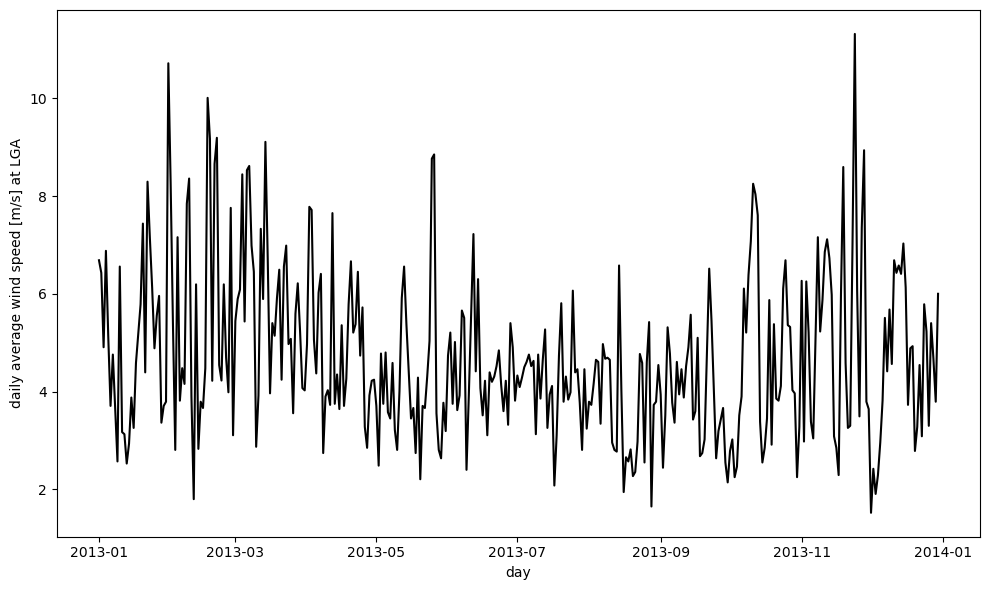

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(daily_mean_windspeed_lga['date'], daily_mean_windspeed_lga['wind_speed'], color='black')
plt.xlabel('day')
plt.ylabel('daily average wind speed [m/s] at LGA')
plt.tight_layout()
plt.show()

**Observation:**
- Wind Speed is highest in November 2013.
- Mid-2013 (likely summer months) appears to have relatively lower wind speeds with less intense fluctuations compared to other periods.
- Peaks are noticeable around specific times, which might correspond to seasonal weather patterns (e.g., higher winds in winter(during November or spring(during feb - march 2013)).

#### Q4. Identify the ten windiest days at LGA (dates and the corresponding mean daily wind speeds).

In [21]:
windiest_days = daily_mean_windspeed_lga.nlargest(10, 'wind_speed') #First 10 largest daily wind speeds
print(" date          wind_speed\n")
for index, row in windiest_days.iterrows():
    print(f"{row['date'].strftime('%Y-%m-%d')}      {row['wind_speed']:.2f}")

 date          wind_speed

2013-11-24      11.32
2013-01-31      10.72
2013-02-17      10.01
2013-02-21      9.19
2013-02-18      9.17
2013-03-14      9.11
2013-11-28      8.94
2013-05-26      8.85
2013-05-25      8.77
2013-02-20      8.66


#### Q5. Compute the monthly mean wind speeds for all the three airports.There is one obvious outlier amongst the observed wind speeds. Locate it (programmatically, do not hardcode the date/day/row number) and replace it with np.nan (NaN) before computing the means.

In [12]:
wind_speed_outlier = df['wind_speed'].idxmax()  # single outlier
df.loc[wind_speed_outlier, 'wind_speed'] = np.nan #replacing it with nan

In [13]:
monthly_mean_wind_speeds = df.groupby(['year', 'month', 'origin'])['wind_speed'].mean().reset_index() #computing mean

#### Q6. Draw the monthly mean wind speeds for the three airports on the same plot (three curves of different colours). 

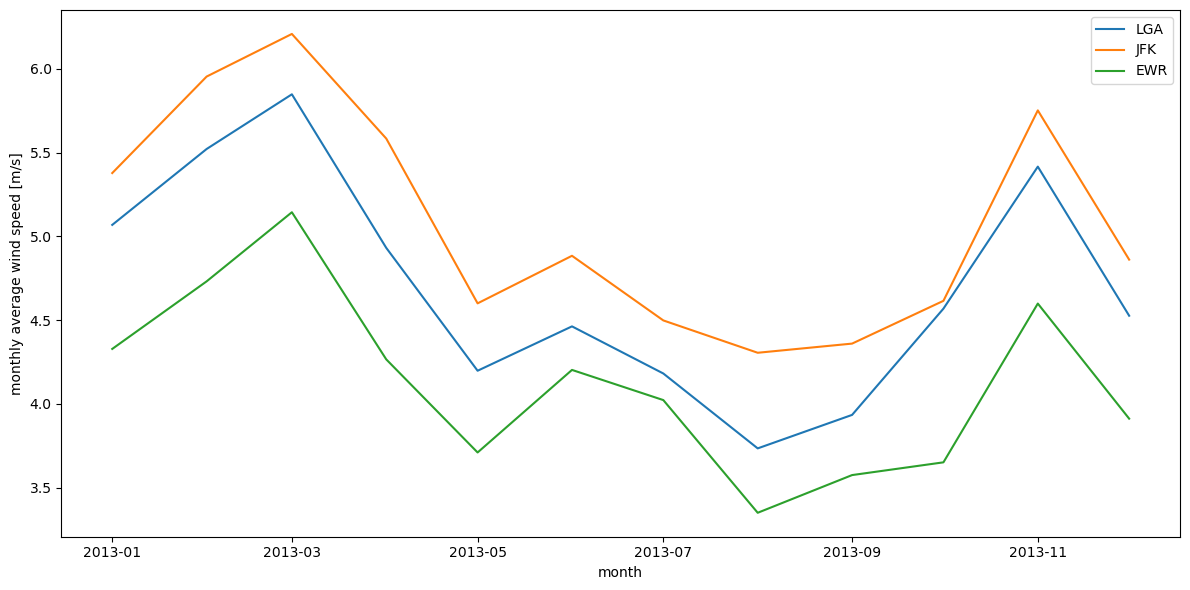

In [14]:
#reshapes the monthly_mean_wind DataFrame into a pivot table
monthly_mean_wind_pivot = monthly_mean_wind_speeds.pivot(index=['year', 'month'], columns='origin', values='wind_speed') 
#Converts the index (which is a combination of year and month) into a datetime object for better plotting.
monthly_mean_wind_pivot.index = pd.to_datetime(monthly_mean_wind_pivot.index.map(lambda x: f"{x[0]}-{x[1]:02d}-01"))

#Plot the Data
plt.figure(figsize=(12, 6))
for airport in ['LGA', 'JFK', 'EWR']:
    plt.plot(monthly_mean_wind_pivot.index, monthly_mean_wind_pivot[airport], label=airport)

plt.xlabel('month')
plt.ylabel('monthly average wind speed [m/s]')
plt.legend()
plt.tight_layout()
plt.show()

Airport Differences:
- JFK consistently experiences the highest wind speeds across all months, peaking in March (~6.5 m/s).
- LGA has wind speeds lower than JFK but higher than EWR for most of the year, showing a similar seasonal trend.
- EWR has the lowest wind speeds throughout the year, with the smallest peak in March (~5 m/s).

During summer (June–August), all airports show significantly lower wind speeds, with values dropping below 5 m/s for EWR and closer to 5 m/s for LGA and JFK.
Wind speeds increase again starting in October, with JFK leading this rise, followed by LGA and then EWR.

### **Conclusion:**

The analysis of hourly meteorological data for New York City airports (JFK, LGA, and EWR) in 2013 reveals distinct seasonal and airport-specific wind speed variations. Wind speeds were highest in November, aligning with typical late autumn and early winter weather patterns. Conversely, mid-2013, particularly the summer months (June–August), experienced significantly lower wind speeds with reduced fluctuations.

Among the three airports, **JFK consistently recorded the highest wind speeds throughout the year**, with a peak in March (6.5 m/s approx). **LGA followed a similar seasonal trend, with wind speeds generally lower than JFK but higher than EWR**. **EWR had the lowest wind speeds, with the smallest peak in March (~5 m/s), and remained consistently lower than the other two airports**.

These patterns suggest that **seasonal changes strongly influence wind speed, with higher values during winter and early spring (November–March) and lower values in summer (June–August)**. The differences across airports could be attributed to their geographical locations and surrounding landscapes, which affect local wind dynamics.

Such insights are valuable for **aviation operations, logistics planning, and airport management**, as understanding wind patterns can help optimize flight scheduling, improve safety measures, and enhance operational efficiency at these major transportation hubs.

### **Optional Features****

In [15]:
# Filter data for JFK airport
jfk_data = df[df['origin'] == 'JFK'].copy()

# Convert the time columns into a single datetime column for easier handling
jfk_data['time_hour'] = pd.to_datetime(jfk_data[['year', 'month', 'day', 'hour']])

# Step 1: Identify Missing Temperature Readings
# Detect missing or omitted records by checking for NaNs and comparing expected timestamps
full_time_range = pd.date_range(start=jfk_data['time_hour'].min(), 
                                end=jfk_data['time_hour'].max(), 
                                freq='H')  # Generate a complete hourly range
missing_times = full_time_range.difference(jfk_data['time_hour'])  # Find missing times

In [16]:
missing_times

DatetimeIndex(['2013-01-01 05:00:00', '2013-02-21 05:00:00',
               '2013-03-05 06:00:00', '2013-03-31 01:00:00',
               '2013-04-03 00:00:00', '2013-08-13 04:00:00',
               '2013-08-16 04:00:00', '2013-08-19 21:00:00',
               '2013-08-22 22:00:00', '2013-08-23 00:00:00',
               '2013-08-23 01:00:00', '2013-10-26 00:00:00',
               '2013-10-26 01:00:00', '2013-10-26 02:00:00',
               '2013-10-26 03:00:00', '2013-10-26 04:00:00',
               '2013-10-27 01:00:00', '2013-11-01 07:00:00',
               '2013-11-01 08:00:00', '2013-11-03 00:00:00',
               '2013-11-03 01:00:00', '2013-11-03 02:00:00',
               '2013-11-03 03:00:00', '2013-11-03 04:00:00',
               '2013-11-04 15:00:00'],
              dtype='datetime64[ns]', freq=None)

In [17]:
# Create a DataFrame for missing timestamps and set all fields to NaN
missing_data = pd.DataFrame({
    'time_hour': missing_times,
    'temp': np.nan,
    'dewp': np.nan,
    'humid': np.nan,
    'wind_dir': np.nan,
    'wind_speed': np.nan,
    'wind_gust': np.nan,
    'precip': np.nan,
    'pressure': np.nan,
    'visib': np.nan,
    'origin': 'JFK'
})

In [18]:
# Append missing data to the original JFK dataset and sort by time
jfk_data_complete = pd.concat([jfk_data, missing_data]).sort_values('time_hour').reset_index(drop=True)

In [19]:
# Step 2: Interpolate Missing Temperatures
jfk_data_complete['temp_interpolated'] = jfk_data_complete['temp'].interpolate(method='linear')

In [20]:
# Step 3: Compute Daily Average Temperatures
# Compute daily average for both raw and interpolated temperatures
jfk_data_complete['date'] = jfk_data_complete['time_hour'].dt.date
daily_avg_temp_raw = jfk_data_complete.groupby('date')['temp'].mean()
daily_avg_temp_interpolated = jfk_data_complete.groupby('date')['temp_interpolated'].mean()

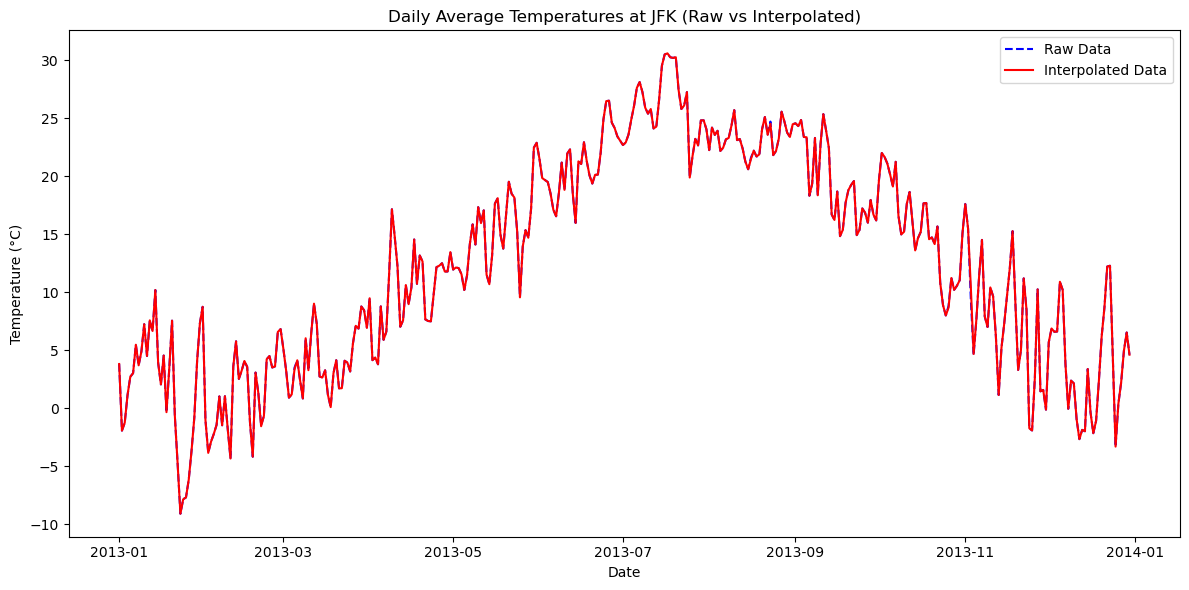

In [21]:
# Step 4: Plot Daily Average Temperatures for Comparison
plt.figure(figsize=(12, 6))
plt.plot(daily_avg_temp_raw.index, daily_avg_temp_raw, label='Raw Data', color='blue', linestyle='--')
plt.plot(daily_avg_temp_interpolated.index, daily_avg_temp_interpolated, label='Interpolated Data', color='red')
plt.title('Daily Average Temperatures at JFK (Raw vs Interpolated)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()